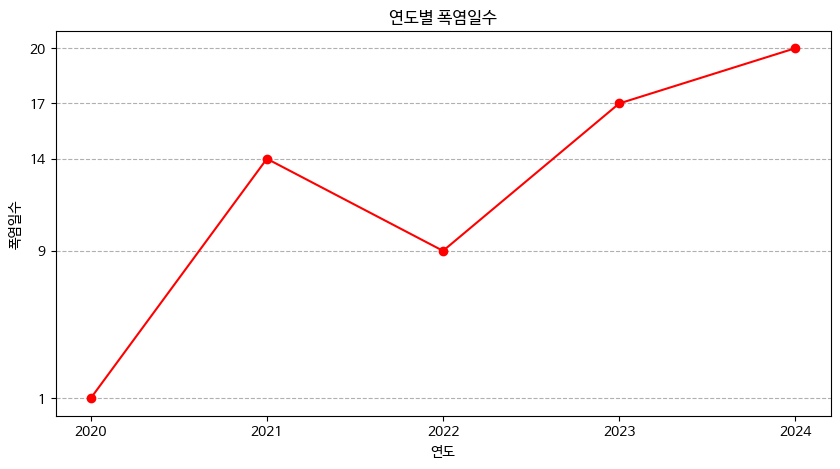

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("천안시_연도별_폭염일수.csv", encoding='cp949')


x = df.iloc[:, 0].astype(int)
y = df.iloc[:, 1]

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker='o', color='red')

plt.title('연도별 폭염일수')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.xticks(x)
plt.yticks(sorted(y.unique()))
plt.grid(axis='y', linestyle='--')


plt.show()

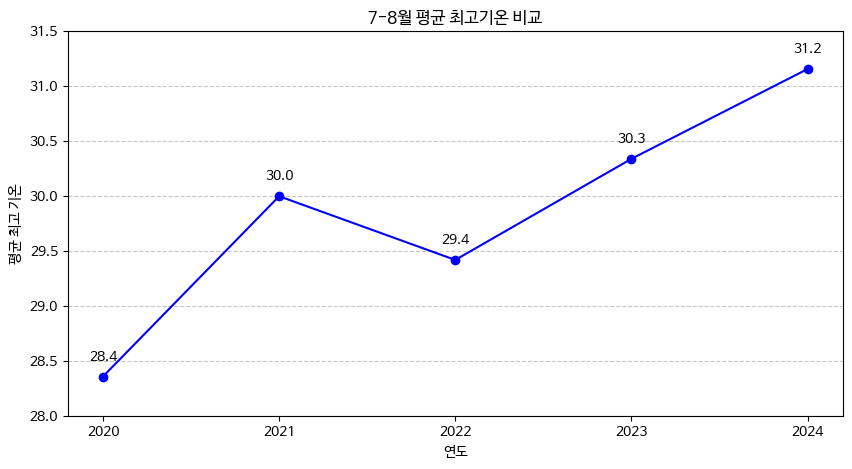

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

df = pd.read_csv("천안7월8.csv", encoding='cp949')
df['날짜'] = pd.to_datetime(df['날짜'])
df_summer = df[df['날짜'].dt.month.isin([7, 8])]
df_summer['연도'] = df_summer['날짜'].dt.year
result = df_summer.groupby('연도')[df.columns[4]].mean()

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

plt.figure(figsize=(10, 5))
result.plot(kind='line', marker='o', color='blue')

plt.title('7-8월 평균 최고기온 비교')
plt.xlabel('연도')
plt.ylabel('평균 최고 기온')
plt.grid(axis='y', linestyle='--', alpha=0.7)

years = result.index.tolist()
plt.xticks(years)
plt.ylim(28, 31.5)
for x, y in zip(result.index, result.values):
    plt.text(x, y+0.15, f'{y:.1f}', ha='center', fontsize=10)

plt.show()


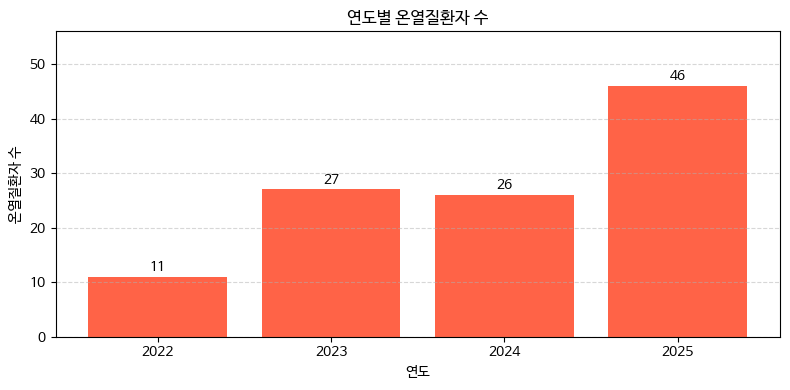

In [ ]:
import matplotlib.pyplot as plt


years = [2022, 2023, 2024, 2025]
num = [11, 27, 26, 46]

# 그래프 그리기
plt.figure(figsize=(8, 4))
plt.bar(years, num, color='tomato')

# 값 표시
for i in range(len(years)):
    plt.text(years[i], num[i] + 1, str(num[i]), ha='center', fontsize=10)

plt.title('연도별 온열질환자 수')
plt.xlabel('연도')
plt.ylabel('온열질환자 수')
plt.xticks(years)
plt.ylim(0, max(num) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

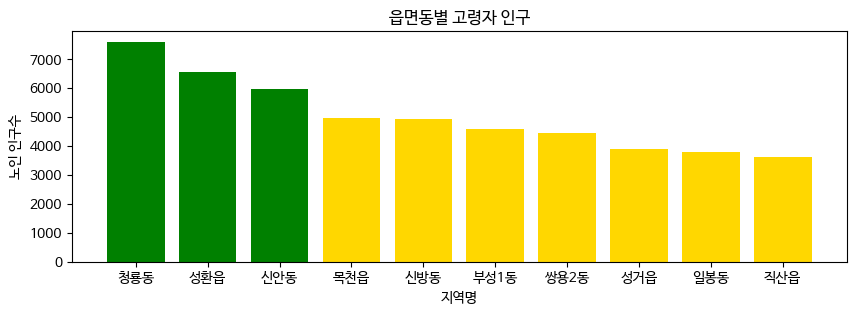

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("읍면동별 고령자 인구.csv", encoding='utf-8')
df_sorted = df.sort_values(by='노인 인구수', ascending=False)
df_top10 = df_sorted.head(10)
x = df_top10.iloc[:, 0]
y = df_top10.iloc[:, 1]
colors = ['green'] * 3 + ['gold'] * (len(y) - 3)
plt.figure(figsize=(10, 3))
plt.bar(x, y, color = colors)

plt.title('읍면동별 고령자 인구')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.show()

In [3]:
import folium
import pandas as pd

dongs = ['청룡동', '성환읍', '신안동']

candidate_files = {
    dong: f'{dong}_후보지(MCLP).csv' for dong in dongs
}

demand_files = {
    dong: {
        '버스': f'{dong}_버스정류장.csv',
        '노인시설': f'{dong}_노인시설.csv',
        '노인복지시설': f'{dong}_노인복지시설.csv',
        '경로당': f'{dong}_경로당.csv',
    }
    for dong in dongs
}

candidate_colors = {
    '청룡동': 'blue',
    '성환읍': 'green',
    '신안동': 'red',
}

demand_colors = {
    '버스': 'orange',
    '노인시설': 'purple',
    '노인복지시설': 'darkred',
    '경로당': 'cadetblue',
}

coord_cols = {
    '버스': ('Y좌표', 'X좌표'),       # (위도, 경도)
    '노인시설': ('위도', '경도'),
    '노인복지시설': ('위도', '경도'),
    '경로당': ('위도', '경도'),
}

all_candidate_points = []

for dong in dongs:
    df = pd.read_csv(candidate_files[dong])
    all_candidate_points.append(df[['위도', '경도']])

all_candidates_concat = pd.concat(all_candidate_points)
center_lat = all_candidates_concat['위도'].mean()
center_lon = all_candidates_concat['경도'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

def add_candidates(df, dong):
    color = candidate_colors[dong]
    for _, row in df.iterrows():
        folium.Marker(
            location=[row['위도'], row['경도']],
            popup=f'{dong} 후보지: {row.get("이름", "")}',
            icon=folium.Icon(color=color, icon='star')
        ).add_to(m)
        folium.Circle(
            location=[row['위도'], row['경도']],
            radius=500,
            color=color,
            fill=True,
            fill_opacity=0.1,
        ).add_to(m)

def add_demand(df, dong, demand_type):
    color = demand_colors[demand_type]
    lat_col, lon_col = coord_cols[demand_type]
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=f'{dong} {demand_type}'
        ).add_to(m)

for dong in dongs:
    candidate_df = pd.read_csv(candidate_files[dong])
    add_candidates(candidate_df, dong)

    for demand_type, file_path in demand_files[dong].items():
        demand_df = pd.read_csv(file_path)
        add_demand(demand_df, dong, demand_type)

m.save('MCLP_통합지도.html')

In [2]:
import folium
import pandas as pd

dongs = ['청룡동', '성환읍', '신안동']

dong_colors = {
    '청룡동': 'blue',
    '성환읍': 'green',
    '신안동': 'red'
}

demand_colors = {
    '버스정류장': 'orange',
    '노인시설': 'purple',
    '노인복지시설': 'darkred',
    '경로당': 'cadetblue'
}

final_candidate_files = {
    '청룡동': '청룡동_후보지(P-median).csv',
    '성환읍': '성환읍_후보지(P-median).csv',
    '신안동': '신안동_후보지(P-median).csv'
}

demand_files = {
    '버스정류장': '{}_버스정류장.csv',
    '노인시설': '{}_노인시설.csv',
    '노인복지시설': '{}_노인복지시설.csv',
    '경로당': '{}_경로당.csv'
}

coord_cols = {
    '버스정류장': ('Y좌표', 'X좌표'),  # 위도, 경도
    '노인시설': ('위도', '경도'),
    '노인복지시설': ('위도', '경도'),
    '경로당': ('위도', '경도')
}


all_coords = []
for dong in dongs:
    df = pd.read_csv(final_candidate_files[dong])
    all_coords.extend(zip(df['위도'], df['경도']))

center_lat = sum([x[0] for x in all_coords]) / len(all_coords)
center_lon = sum([x[1] for x in all_coords]) / len(all_coords)


m = folium.Map(location=[center_lat, center_lon], zoom_start=13)


for dong in dongs:
    df = pd.read_csv(final_candidate_files[dong])
    for _, row in df.iterrows():
        folium.Marker(
            location=[row['위도'], row['경도']],
            popup=f"[{dong}] {row['이름']}",
            icon=folium.Icon(color=dong_colors[dong], icon='star')
        ).add_to(m)
        folium.Circle(
            location=[row['위도'], row['경도']],
            radius=500,
            color=dong_colors[dong],
            fill=True,
            fill_opacity=0.1
        ).add_to(m)


for dong in dongs:
    for demand_type, file_template in demand_files.items():
        file = file_template.format(dong)
        df = pd.read_csv(file)
        lat_col, lon_col = coord_cols[demand_type]
        for _, row in df.iterrows():
            folium.CircleMarker(
                location=[row[lat_col], row[lon_col]],
                radius=3,
                color=demand_colors[demand_type],
                fill=True,
                fill_opacity=0.5,
                popup=f"[{dong}] {demand_type}"
            ).add_to(m)

m.save("pmedian_후보지_시각화.html")

In [1]:
import pandas as pd
import folium
from folium.plugins import BeautifyIcon

최종후보지 = pd.read_csv("최종후보지.csv")

top5 = 최종후보지.head(5)

center_lat = top5.iloc[:, 1].mean()
center_lon = top5.iloc[:, 2].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

for i, row in top5.iterrows():
    name = row[0]
    lat = row[1]
    lon = row[2]

    icon = BeautifyIcon(
        icon_shape='marker',
        icon='star',
        background_color='blue',
        text_color='white',
        border_color='white'
    )

    folium.Marker(
        location=[lat, lon],
        icon=icon
    ).add_to(m)

    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(html=f"""
            <div style="font-size: 20px; color: black; white-space: nowrap;">
                {name}
            </div>
        """)
    ).add_to(m)

m.save("최종후보지_top5.html")

/tmp/ipython-input-2875986311.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  name = row[0]
/tmp/ipython-input-2875986311.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lat = row[1]
/tmp/ipython-input-2875986311.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lon = row[2]
